In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print(df.describe())
print(df["Churn"].value_counts())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [6]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Valero\AppData\Local\Temp\ipykernel_13380\2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [10]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


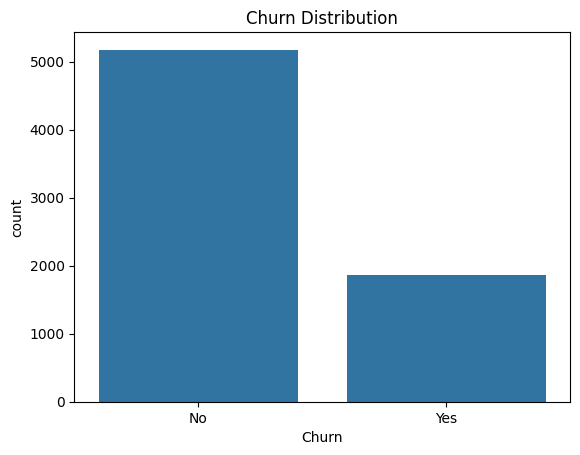

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()


In [12]:
plt.savefig('visuals/churn_distribution.png')

<Figure size 640x480 with 0 Axes>

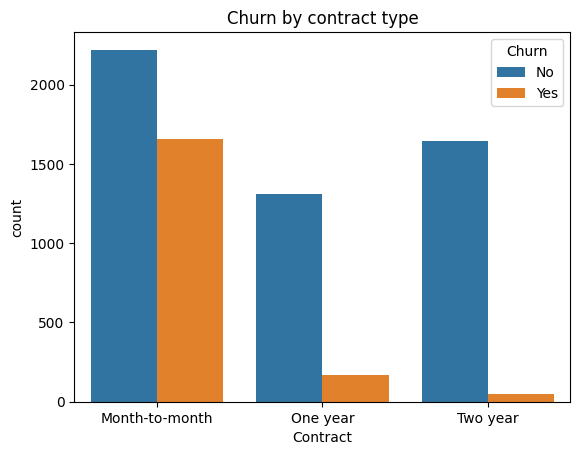

In [13]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by contract type')
plt.show()


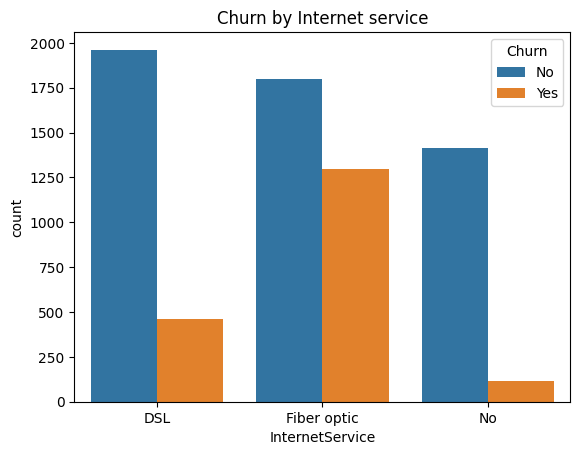

In [14]:
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet service')
plt.show()


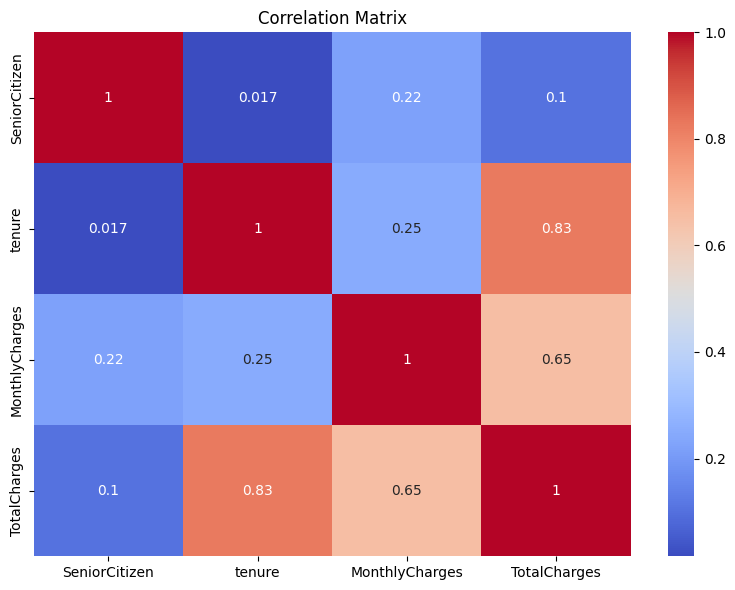

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('visuals/correlation_matrix.png')
plt.show()

In [16]:
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']


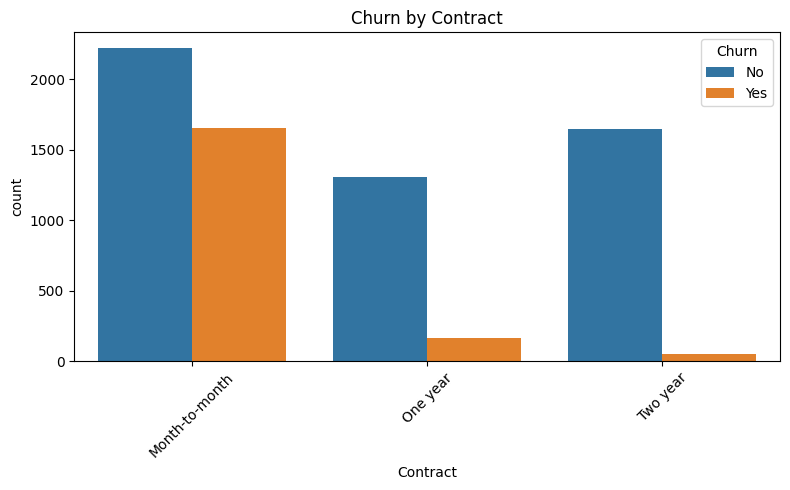

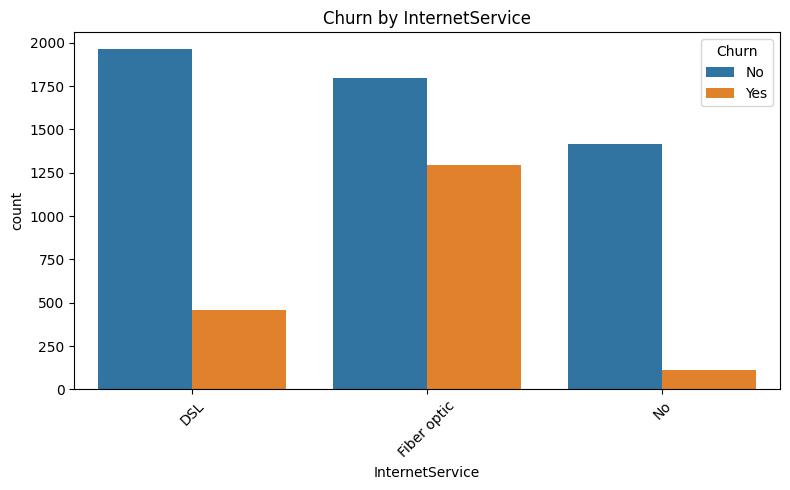

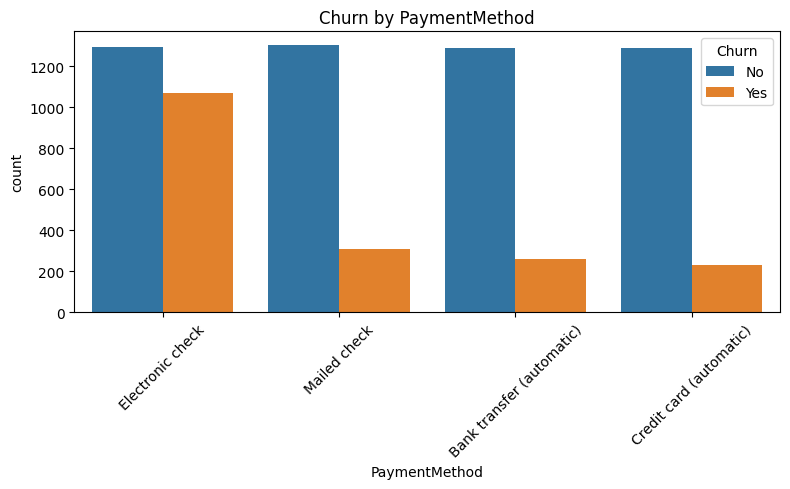

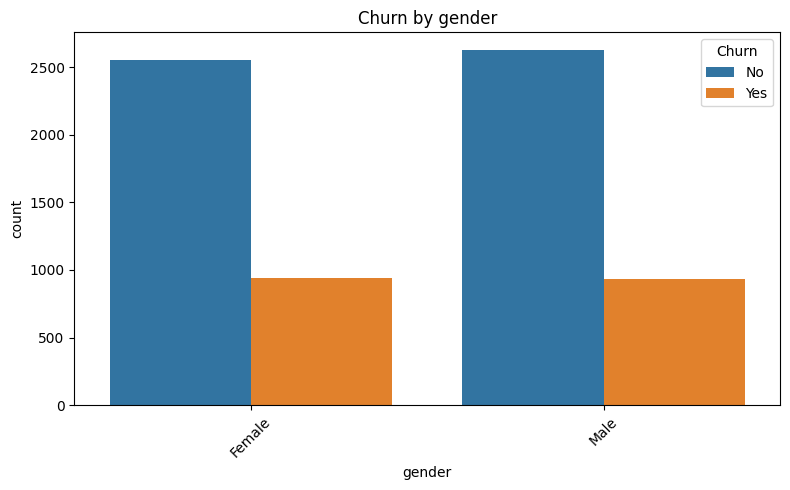

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'visuals/churn_{col}.png')
    plt.show()


In [18]:
insights_uk = [
    "Customers on month-to-month contracts have a higher risk of churn compared to annual contracts.",
    "Customers using Fiber optic internet service are more likely to churn than those with DSL.",
    "Customers paying with electronic check tend to churn more frequently than other payment methods.",
    "Gender does not show a significant impact on churn in this dataset."]

In [19]:
for i, insight in enumerate(insights_uk, 1):
    print(f"{i}. {insight}")

1. Customers on month-to-month contracts have a higher risk of churn compared to annual contracts.
2. Customers using Fiber optic internet service are more likely to churn than those with DSL.
3. Customers paying with electronic check tend to churn more frequently than other payment methods.
4. Gender does not show a significant impact on churn in this dataset.


In [20]:
high_risk_uk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic')
]

In [21]:
print(f"\nNumber of high-risk customers: {len(high_risk_uk)}")


Number of high-risk customers: 2128


In [22]:
high_risk_uk.to_csv('data/processed/high_risk_customers_uk.csv', index=False)


In [23]:
recommendations_uk = [
    "Offer retention incentives for customers on month-to-month contracts.",
    "Provide proactive support and personalized offers for customers with Fiber optic internet.",
    "Review payment methods and consider strategies to reduce churn among electronic check users.",
    "Focus retention strategies on service and contract type rather than demographics like gender."
]

In [24]:
print("\nBusiness Recommendations:")
for i, rec in enumerate(recommendations_uk, 1):
    print(f"{i}. {rec}")


Business Recommendations:
1. Offer retention incentives for customers on month-to-month contracts.
2. Provide proactive support and personalized offers for customers with Fiber optic internet.
3. Review payment methods and consider strategies to reduce churn among electronic check users.
4. Focus retention strategies on service and contract type rather than demographics like gender.


In [25]:
df.to_csv('data/processed/churn_clean.csv', index=False)
